# 세그먼트 · 여행패턴별 1인당 소비 비교

`SQL/JeongTaeChoi/Read/segment_hypothesis_tutorial.sql`(가설 검증용 튜토리얼 SQL)과
같은 대화에서 실제로 실행한 분석을 노트북으로 옮긴 것입니다. 목적은 "어떤 세그먼트나
여행패턴이 상대적으로 소비가 낮은지"를 표 + 차트로 눈으로 확인하는 것입니다.

**전제 (데이터분석 보고 7원칙 적용)**
- 표본: 2023년 수도권 자체 수집 여행로그 데이터, 여행(TRAVEL_ID) 단위 2,880건
  (이 중 소비 기록이 하나도 없는 1건은 아래 분석에서 자연스럽게 제외되어 n=2,879)
- 소비 정의: 활동소비 + 사전소비 + 숙박소비 + 이동수단소비 합계 (2026-08-06 대화에서
  사전소비도 포함하기로 결정 — 최종 확정은 STEP 1-4~1-6 샘플 확인 후 팀 트래커에 기록할 것)
- 1인당 소비 = 위 총소비 / (tn_companion_info 동반자 수 + 본인 1명)
- 틈(gap) 정의: 연속 방문지 도착시각 차이 - 체류시간(RESIDENCE_TIME_MIN), 숙소/집/
  지인집/사무실/역·터미널/기타(VISIT_AREA_TYPE_CD 9,12,21,22,23,24)는 계산에서 제외
  (RESIDENCE_TIME_MIN·gap 모두 30분 단위로만 기록되는 근본적 한계가 있음 — 맨 아래 한계 참고)

In [1]:
import os
# 운영체제 관련 기능(환경변수 등)을 다루기 위한 표준 라이브러리
import pandas as pd
# 데이터프레임으로 데이터를 다루기 위한 라이브러리
import matplotlib.pyplot as plt
# 그래프를 그리기 위한 라이브러리
from dotenv import load_dotenv, find_dotenv
# .env 파일에서 환경변수를 불러오기 위한 함수들
from sqlalchemy import create_engine
# DB 연결 엔진을 생성하기 위한 함수


plt.rcParams['font.family'] = 'Malgun Gothic'
# 그래프에서 기본으로 쓸 폰트를 한글 지원 폰트(맑은 고딕)로 지정
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지
%matplotlib inline
# 그래프를 새 창이 아니라 셀 바로 아래에 표시하도록 설정

env_path = find_dotenv()
# 현재 프로젝트에서 .env 파일 경로를 자동으로 찾음
load_dotenv(env_path)
# 찾은 .env 파일의 내용을 환경변수로 불러옴
env_dir = os.path.dirname(env_path)
# .env 파일이 있는 폴더 경로 (인증서 파일 경로 계산에 사용)

HOST = os.environ["AIVEN_HOST"]
# DB 서버 주소
PORT = int(os.environ["AIVEN_PORT"])
# DB 포트 번호 (문자열을 정수로 변환)
USER = os.environ["AIVEN_USER"]
# DB 접속 계정
PASSWORD = os.environ["AIVEN_PASSWORD"]
# DB 접속 비밀번호
DB = os.environ["AIVEN_DB"]
# 접속할 데이터베이스 이름
CA_CERT_PATH = os.path.join(env_dir, os.environ["AIVEN_CA_CERT_PATH"])
# SSL 접속에 필요한 인증서 파일의 전체 경로

engine = create_engine(
    f"mysql+pymysql://{USER}:{PASSWORD}@{HOST}:{PORT}/{DB}",
    connect_args={"ssl_ca": CA_CERT_PATH, "ssl_verify_cert": True}
)
# 위 접속 정보로 SSL 연결을 사용하는 DB 엔진 생성

MIN_N = 30
# 세그먼트 표본수가 이 값보다 작으면 평균이 소수 극단값에 흔들리므로 차트에서 제외
# (segment_hypothesis_tutorial.sql STEP 1-11과 동일 기준, 임계값은 팀이 조정 가능)

df_test = pd.read_sql("SELECT COUNT(*) AS cnt FROM tn_travel", engine)
# 연결 테스트: tn_travel 전체 행 수 조회
print(df_test)

    cnt
0  2880


## 1. 파생변수 만들기 — 1인당 소비, 틈 비율, 동반유형

In [2]:
per_person_sql = """
WITH travel_total_consume AS (
    SELECT c.TRAVEL_ID, SUM(c.PAYMENT_AMT_WON) AS total_amt_won
    FROM (
        SELECT TRAVEL_ID, PAYMENT_AMT_WON FROM tn_activity_consume_his
        UNION ALL
        SELECT TRAVEL_ID, PAYMENT_AMT_WON FROM tn_adv_consume_his
        UNION ALL
        SELECT TRAVEL_ID, PAYMENT_AMT_WON FROM tn_lodge_consume_his
        UNION ALL
        SELECT TRAVEL_ID, PAYMENT_AMT_WON FROM tn_mvmn_consume_his
    ) c
    GROUP BY c.TRAVEL_ID
),
travel_companion_cnt AS (
    SELECT t.TRAVEL_ID, COALESCE(cc.companion_cnt, 0) AS companion_cnt
    FROM tn_travel t
    LEFT JOIN (
        SELECT TRAVEL_ID, COUNT(*) AS companion_cnt
        FROM tn_companion_info
        GROUP BY TRAVEL_ID
    ) cc ON cc.TRAVEL_ID = t.TRAVEL_ID
)
SELECT
    tc.TRAVEL_ID,
    tc.total_amt_won,
    tcc.companion_cnt + 1 AS person_cnt,
    tc.total_amt_won / (tcc.companion_cnt + 1) AS per_person_amt
FROM travel_total_consume tc
JOIN travel_companion_cnt tcc ON tcc.TRAVEL_ID = tc.TRAVEL_ID
"""
# 활동+사전+숙박+이동수단 소비를 여행(TRAVEL_ID) 단위로 합산하고,
# 동반자수(+본인 1명)로 나눠 1인당 소비를 만드는 쿼리
# (tn_lodge_consume_his는 자연키가 없어 중복 존재가 확인된 테이블이라,
#  여기서는 중복 제거 없이 그대로 합산했다는 전처리 한계가 있음 — 맨 아래 한계 참고)

per_person = pd.read_sql(per_person_sql, engine)
# 쿼리를 실행해 여행 단위 1인당 소비 데이터프레임 생성

print(f"표본 여행수: {len(per_person)}건")
print(f"평균 인당소비: {per_person['per_person_amt'].mean():,.0f}원")
print(f"중앙값 인당소비: {per_person['per_person_amt'].median():,.0f}원")
# 표본 개수와 대표값을 먼저 확인 (7원칙: 표본 개수 명시)

표본 여행수: 2879건
평균 인당소비: 94,231원
중앙값 인당소비: 60,904원


In [3]:
gap_sql = """
WITH arrivals AS (
    SELECT
        v.TRAVEL_ID, v.VISIT_AREA_TYPE_CD, v.RESIDENCE_TIME_MIN, v.VISIT_ORDER,
        m.END_DT_MIN AS arrive_dt,
        LEAD(m.END_DT_MIN) OVER (PARTITION BY v.TRAVEL_ID ORDER BY v.VISIT_ORDER) AS next_arrive_dt
    FROM tn_visit_area_info v
    JOIN tn_move_his m ON m.TRAVEL_ID = v.TRAVEL_ID AND m.TRIP_ID = v.VISIT_AREA_ID
    WHERE m.END_DT_MIN IS NOT NULL
      AND v.VISIT_AREA_TYPE_CD NOT IN ('9','12','21','22','23','24')
)
SELECT
    TRAVEL_ID,
    COUNT(*) AS gap_segment_cnt,
    SUM((TIMESTAMPDIFF(MINUTE, arrive_dt, next_arrive_dt) - RESIDENCE_TIME_MIN) > 0) AS gap_segment_with_gap
FROM arrivals
WHERE next_arrive_dt IS NOT NULL
  AND TIMESTAMPDIFF(MINUTE, arrive_dt, next_arrive_dt) > 0
GROUP BY TRAVEL_ID
"""
# 연속 방문지 도착시각 차이(gap_minutes)에서 체류시간을 뺀 residual이 양수인
# 구간의 비율을 여행 단위 "틈 발생 비율"로 계산 (segment_hypothesis_tutorial.sql STEP 3-2와 동일 로직)

gap = pd.read_sql(gap_sql, engine)
# 쿼리 실행

gap["gap_ratio"] = gap["gap_segment_with_gap"] / gap["gap_segment_cnt"]
# 여행 단위 틈 발생 비율 = 틈 있는 구간 수 / 전체 구간 수

print(f"틈 비율 계산 가능한 여행수: {len(gap)}건 (전체 {len(per_person)}건 중)")
# 방문지가 1곳뿐이거나 전부 제외 유형인 여행은 틈 계산 대상에서 자연히 빠짐

틈 비율 계산 가능한 여행수: 2717건 (전체 2879건 중)


In [4]:
travel = pd.read_sql("SELECT TRAVEL_ID, TRAVELER_ID FROM tn_travel", engine)
# 여행-여행자 매핑

traveller = pd.read_sql(
    "SELECT TRAVELER_ID, GENDER, AGE_GRP, JOB_NM, INCOME FROM tn_traveller_master", engine
)
# 여행자 세그먼트 기준 컬럼(성별/연령대/직업코드/소득코드)

companion = pd.read_sql(
    "SELECT TRAVEL_ID, COUNT(*) AS companion_cnt FROM tn_companion_info GROUP BY TRAVEL_ID", engine
)
# 여행별 동반자 수 (companion_info에 행이 없으면 나홀로 여행으로 간주)

revisit = pd.read_sql("""
    SELECT TRAVEL_ID, MAX(CASE WHEN REVISIT_YN = 'Y' THEN 1 ELSE 0 END) AS has_revisit
    FROM tn_visit_area_info
    GROUP BY TRAVEL_ID
""", engine)
# 여행 안에 REVISIT_YN='Y'(재방문 응답)인 방문지가 하나라도 있으면 1

df = per_person.merge(travel, on="TRAVEL_ID", how="left")
df = df.merge(traveller, on="TRAVELER_ID", how="left")
df = df.merge(gap[["TRAVEL_ID", "gap_ratio"]], on="TRAVEL_ID", how="left")
df = df.merge(companion, on="TRAVEL_ID", how="left")
df["companion_cnt"] = df["companion_cnt"].fillna(0)
df = df.merge(revisit, on="TRAVEL_ID", how="left")
# 지금까지 만든 조각들을 여행(TRAVEL_ID) 단위 하나의 표로 합침

def companion_type(n):
    # 동반자 수를 세 구간(나홀로/2인/3인이상)으로 나누는 함수
    if n == 0:
        return "나홀로"
    elif n == 1:
        return "2인 동반"
    else:
        return "3인 이상 동반"

df["companion_type"] = df["companion_cnt"].apply(companion_type)
# 동반유형 컬럼 생성

df["revisit_group"] = df["has_revisit"].map({1: "재방문 포함 여행", 0: "첫방문만 있는 여행"})
# 재방문여부(응답 기준) 컬럼을 사람이 읽을 문자열로 변환

df.head()
# 최종 결합 결과 미리보기

,TRAVEL_ID,total_amt_won,person_cnt,per_person_amt,TRAVELER_ID,GENDER,AGE_GRP,JOB_NM,INCOME,gap_ratio,companion_cnt,has_revisit,companion_type,revisit_group
0,e_e000006,72100.0,2,36050.0,e000006,남,30,3,5,0.500000,1.0,1,2인 동반,재방문 포함 여행
1,e_e000009,353140.0,2,176570.0,e000009,여,30,3,4,0.800000,1.0,1,2인 동반,재방문 포함 여행
2,e_e000010,528670.0,1,528670.0,e000010,여,30,3,4,0.500000,0.0,1,나홀로,재방문 포함 여행
3,e_e000011,1178100.0,4,294525.0,e000011,여,60,2,7,0.666667,3.0,1,3인 이상 동반,재방문 포함 여행
4,e_e000013,499220.0,4,124805.0,e000013,여,20,3,4,1.000000,3.0,1,3인 이상 동반,재방문 포함 여행


## 2. 코드값 디코딩 — 직업(JOB_NM), 소득(INCOME)

`JOB_NM`, `INCOME`은 숫자 코드라 그대로는 의미를 알 수 없습니다. `tc_codea`에서 어느
`cd_a` 그룹이 직업/소득인지 먼저 확인한 뒤(`JOB`, `INC`로 확인됨), `tc_codeb`에서
실제 이름을 가져옵니다.

In [5]:
job_map_df = pd.read_sql("SELECT cd_b, cd_nm FROM tc_codeb WHERE cd_a = 'JOB'", engine)
# 직업 코드(JOB_NM 1~13) -> 직업명 매핑 조회
income_map_df = pd.read_sql("SELECT cd_b, cd_nm FROM tc_codeb WHERE cd_a = 'INC'", engine)
# 소득 코드(INCOME 1~12) -> 소득구간명 매핑 조회

job_map = dict(zip(job_map_df["cd_b"].astype(str), job_map_df["cd_nm"]))
income_map = dict(zip(income_map_df["cd_b"].astype(str), income_map_df["cd_nm"]))
# {코드문자열: 이름} 딕셔너리로 변환

df["직업명"] = df["JOB_NM"].astype("Int64").astype(str).map(job_map)
df["소득구간명"] = df["INCOME"].astype("Int64").astype(str).map(income_map)
# 숫자 코드 컬럼을 사람이 읽을 수 있는 이름 컬럼으로 치환 (원본 숫자 컬럼은 그대로 보존)

df[["JOB_NM", "직업명", "INCOME", "소득구간명"]].drop_duplicates().sort_values("JOB_NM")
# 매핑이 제대로 됐는지 확인

,JOB_NM,직업명,INCOME,소득구간명
21,1,관리자,4,월평균 200만원 ~ 300만원 미만
377,1,관리자,6,월평균 400만원 ~ 500만원 미만
275,1,관리자,5,월평균 300만원 ~ 400만원 미만
117,1,관리자,10,월평균 800만원 ~ 900만원 미만
327,1,관리자,3,월평균 100만원 ~ 200만원 미만
...,...,...,...,...
15,13,기타,6,월평균 400만원 ~ 500만원 미만
25,13,기타,4,월평균 200만원 ~ 300만원 미만
36,13,기타,3,월평균 100만원 ~ 200만원 미만
2176,13,기타,7,월평균 500만원 ~ 600만원 미만


## 3. 세그먼트별 평균 인당소비 시각화

표본수 30건 미만인 세그먼트는 평균이 소수 극단값에 흔들릴 수 있어 차트에서 제외합니다(`MIN_N`).
막대그래프는 팀 원칙에 따라 Y축을 0부터 시작합니다.

         표본수  평균_인당소비  중앙값_인당소비
GENDER                         
남       1212  89296.0   59875.0
여       1666  97821.0   62225.0


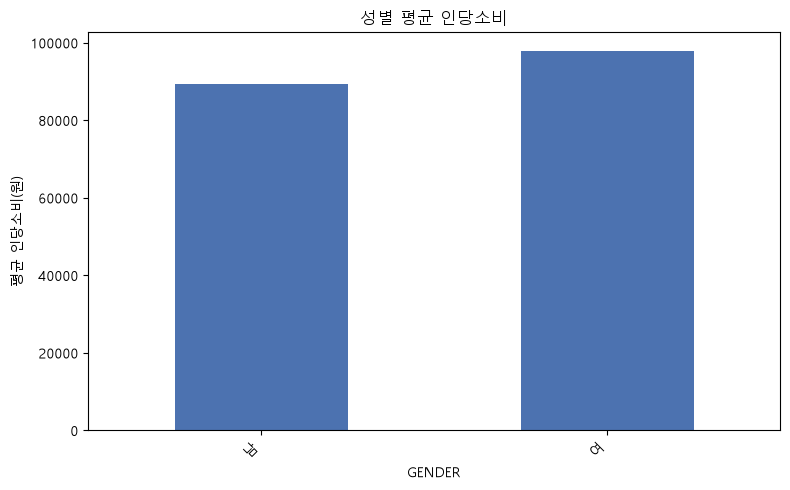

In [6]:
def plot_segment(group_col, title, min_n=MIN_N, sort_values=True, figsize=(8, 5)):
    # 세그먼트 컬럼 하나를 받아 표본수/평균/중앙값 표를 만들고, 평균 기준 막대그래프를 그리는 공용 함수
    g = df.groupby(group_col)["per_person_amt"].agg(["count", "mean", "median"])
    g.columns = ["표본수", "평균_인당소비", "중앙값_인당소비"]
    g = g[g["표본수"] >= min_n]
    # 표본수 30 미만 세그먼트 제외
    if sort_values:
        g = g.sort_values("평균_인당소비")
    print(g.round(0))
    # 차트 그리기 전에 표도 함께 출력 (7원칙: 표 -> 차트 순서)

    ax = g["평균_인당소비"].plot(kind="bar", figsize=figsize, color="#4C72B0")
    ax.set_title(title)
    ax.set_xlabel(group_col)
    ax.set_ylabel("평균 인당소비(원)")
    ax.set_ylim(bottom=0)
    # Y축 0부터 시작 (팀 데이터분석 원칙)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
    return g

_ = plot_segment("GENDER", "성별 평균 인당소비")

          표본수   평균_인당소비  중앙값_인당소비
AGE_GRP                          
20       1062  107998.0   72595.0
30        998   97572.0   64225.0
40        483   75442.0   46994.0
50        111   85722.0   46327.0
60        224   58808.0   43638.0


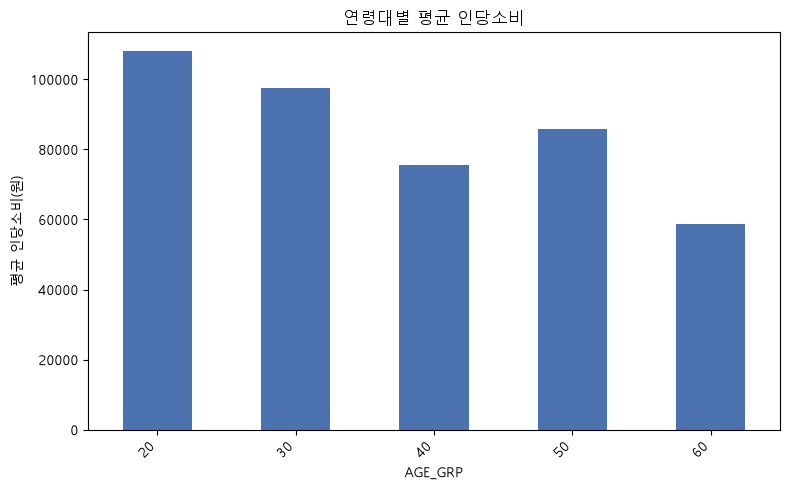

In [7]:
_ = plot_segment("AGE_GRP", "연령대별 평균 인당소비", sort_values=False)
# 연령대는 크기순 비교가 더 직관적이라 정렬하지 않고 코드값(나이) 순서 그대로 사용

                  표본수   평균_인당소비  중앙값_인당소비
직업명                                      
전업주부              181   66822.0   45275.0
서비스 종사자           212   83137.0   60424.0
기타                145   89301.0   60050.0
전문가 및 관련 종사자      733   90074.0   61540.0
학생                370   92793.0   64780.0
판매 종사자             46   95404.0   60066.0
사무 종사자           1021  100717.0   62106.0
관리자                59  108536.0   58483.0
기능원 및 관련 기능 종사자    40  161398.0   77175.0


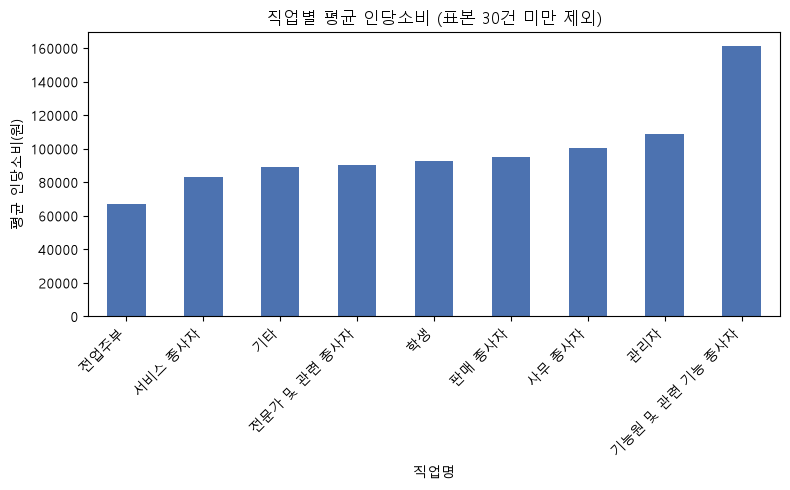

In [8]:
_ = plot_segment("직업명", "직업별 평균 인당소비 (표본 30건 미만 제외)")

                      표본수   평균_인당소비  중앙값_인당소비
소득구간명                                        
소득없음                  354   77746.0   52905.0
월평균 600만원 ~ 700만원 미만   52   79582.0   47142.0
월평균 100만원 ~ 200만원 미만  299   85311.0   58550.0
월평균 500만원 ~ 600만원 미만  138   87136.0   59141.0
월평균 100만원 미만          336   88597.0   60254.0
월평균 400만원 ~ 500만원 미만  242   91194.0   58517.0
월평균 300만원 ~ 400만원 미만  556   98405.0   64183.0
월평균 200만원 ~ 300만원 미만  836  106416.0   68275.0


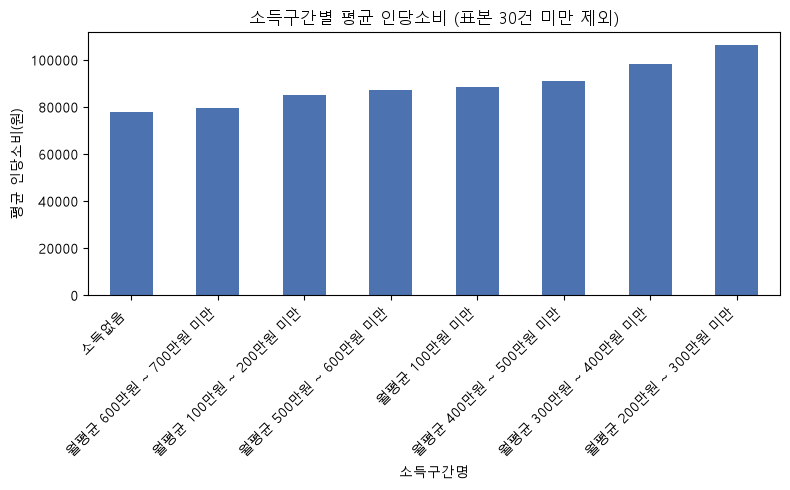

In [9]:
_ = plot_segment("소득구간명", "소득구간별 평균 인당소비 (표본 30건 미만 제외)")

## 4. 여행 패턴별 평균 인당소비 시각화

가설1(틈-소비), 가설3(동반유형-소비), 가설2(재방문-소비)와 직접 연결되는 부분입니다.

          표본수  평균_틈비율     평균_인당소비
틈비율_사분위                          
Q1(틈 적음)  682   0.149   70789.256
Q2        724   0.497   95355.650
Q3        633   0.717  133592.740
Q4(틈 많음)  678   0.999   90786.626


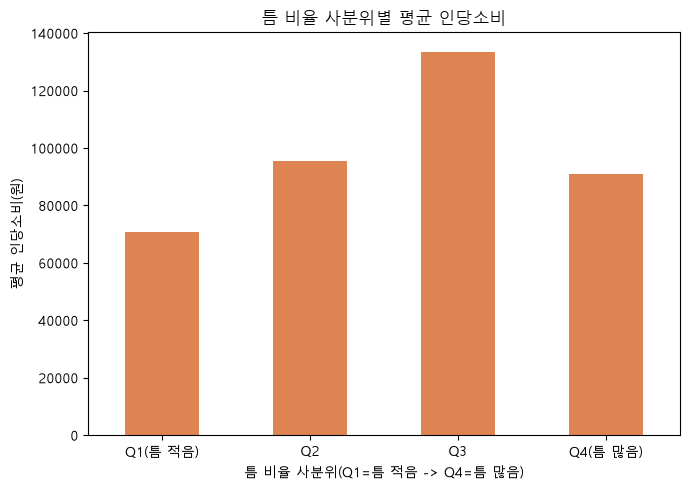

In [10]:
df_gap = df.dropna(subset=["gap_ratio"]).copy()
# 틈 비율을 계산할 수 없었던 여행(방문지 1곳뿐 등) 제외

df_gap["틈비율_사분위"] = pd.qcut(
    df_gap["gap_ratio"], 4,
    labels=["Q1(틈 적음)", "Q2", "Q3", "Q4(틈 많음)"],
    duplicates="drop",
)
# 틈 비율을 표본수가 같도록 4구간(사분위)으로 나눔 — 계획서 가설1 검정 방식과 동일

g = df_gap.groupby("틈비율_사분위", observed=True).agg(
    표본수=("per_person_amt", "count"),
    평균_틈비율=("gap_ratio", "mean"),
    평균_인당소비=("per_person_amt", "mean"),
)
print(g.round(3))

ax = g["평균_인당소비"].plot(kind="bar", figsize=(7, 5), color="#DD8452")
ax.set_title("틈 비율 사분위별 평균 인당소비")
ax.set_xlabel("틈 비율 사분위(Q1=틈 적음 -> Q4=틈 많음)")
ax.set_ylabel("평균 인당소비(원)")
ax.set_ylim(bottom=0)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
# 가설1은 "틈이 적을수록(Q1) 소비가 많다"였는데, 실제로 Q1이 더 높은지 이 차트로 바로 확인 가능

                 표본수   평균_인당소비  중앙값_인당소비
companion_type                          
나홀로              628  138874.0   82550.0
2인 동반           1379   94197.0   68150.0
3인 이상 동반         871   62097.0   45486.0


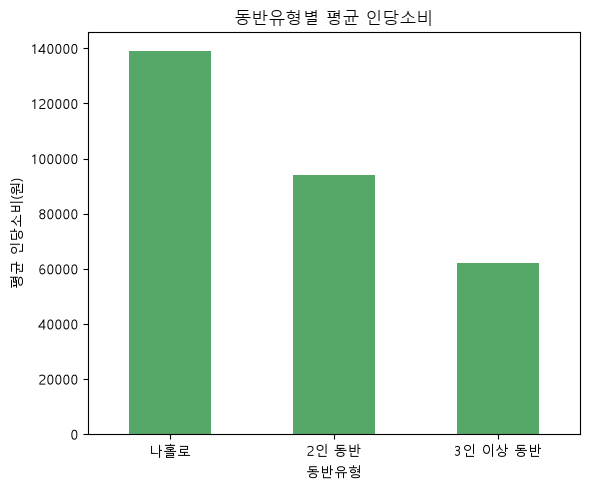

In [11]:
g = df.groupby("companion_type")["per_person_amt"].agg(["count", "mean", "median"])
g.columns = ["표본수", "평균_인당소비", "중앙값_인당소비"]
g = g.reindex(["나홀로", "2인 동반", "3인 이상 동반"])
# 인원이 늘어나는 순서대로 보이도록 정렬 순서를 직접 지정
print(g.round(0))

ax = g["평균_인당소비"].plot(kind="bar", figsize=(6, 5), color="#55A868")
ax.set_title("동반유형별 평균 인당소비")
ax.set_xlabel("동반유형")
ax.set_ylabel("평균 인당소비(원)")
ax.set_ylim(bottom=0)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
# 가설3("나홀로가 가족동반보다 인당 소비가 크다")과 방향이 맞는지 확인

                표본수   평균_인당소비  중앙값_인당소비
revisit_group                          
첫방문만 있는 여행      915   73300.0   54350.0
재방문 포함 여행      1963  103988.0   64125.0


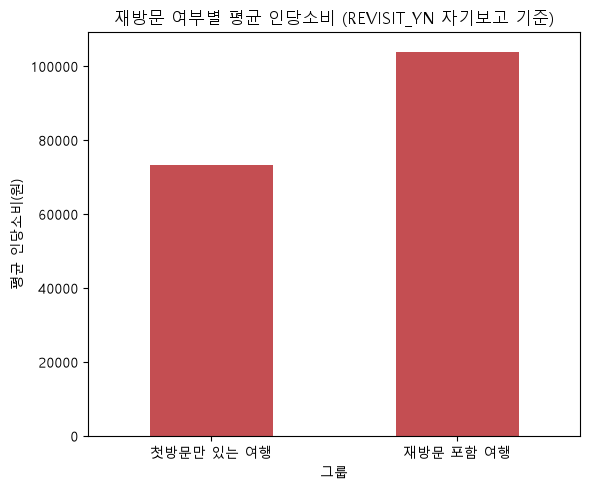

In [12]:
g = df.groupby("revisit_group")["per_person_amt"].agg(["count", "mean", "median"])
g.columns = ["표본수", "평균_인당소비", "중앙값_인당소비"]
g = g.reindex(["첫방문만 있는 여행", "재방문 포함 여행"])
print(g.round(0))

ax = g["평균_인당소비"].plot(kind="bar", figsize=(6, 5), color="#C44E52")
ax.set_title("재방문 여부별 평균 인당소비 (REVISIT_YN 자기보고 기준)")
ax.set_xlabel("그룹")
ax.set_ylabel("평균 인당소비(원)")
ax.set_ylim(bottom=0)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
# 가설2("재방문한 고객의 소비가 더 적다")와 방향이 맞는지 확인
# 주의: 여기서 "재방문"은 여행 안의 방문지 중 하나라도 REVISIT_YN='Y'면 그 여행 전체를
# 재방문군으로 묶은 것이라, 방문지가 많은(=원래 오래/많이 다닌) 여행일수록 재방문
# 표시가 하나라도 나올 확률 자체가 높아지는 구조적 편향이 있을 수 있음(아래 한계 참고)

## 5. 한계 및 반대 해석 (데이터분석 보고 7원칙 6번)

In [13]:
print("[표본/시점]")
print(f"- 2023년 수도권 자체 수집 단일 표본(1인당 소비 계산 가능 {len(df)}건)이라 전국·타 연도로 일반화 불가")
print()
print("[교란요인]")
print("- 성별·연령대·직업·소득·동반유형 등 세그먼트가 서로 얽혀 있어(예: 20대·나홀로·")
print("  전업주부가 겹칠 수 있음) 이 노트북의 단순 그룹 평균만으로는 어떤 요인이 진짜")
print("  원인인지 분리할 수 없음 (다변량 통제 분석이 아닌 기술통계 수준)")
print()
print("[측정 한계]")
print("- RESIDENCE_TIME_MIN과 gap_minutes 모두 30분 단위로만 기록되어, 30분 미만의")
print("  유휴시간은 원천적으로 관측 불가")
print("- REVISIT_YN은 응답자의 자기보고(체감) 값이며, '재방문 포함 여행' 판정은 여행")
print("  안의 방문지 중 하나라도 Y면 전체를 재방문군으로 묶은 것이라 방문지 수가 많은")
print("  여행일수록 재방문군으로 분류될 확률 자체가 높아지는 구조적 편향이 있을 수 있음")
print()
print("[전처리 한계]")
print("- tn_lodge_consume_his(숙박소비)는 자연키가 없어 중복 존재가 확인된 테이블인데,")
print("  이 노트북에서는 중복 제거 없이 그대로 합산함 -> 숙박비가 실제보다 부풀려졌을 가능성")
print("- 사전소비(tn_adv_consume_his)를 포함해 재계산함(2026-08-06 결정). ADV_NM(구매내역명)이")
print("  '여행 전 준비물/예약비용 추정'이라는 정도만 확인된 상태라, 성격이 다른 지출(예:")
print("  여행과 무관한 사전 구매)이 섞여 있을 가능성은 아직 배제하지 못함")

[표본/시점]
- 2023년 수도권 자체 수집 단일 표본(1인당 소비 계산 가능 2879건)이라 전국·타 연도로 일반화 불가

[교란요인]
- 성별·연령대·직업·소득·동반유형 등 세그먼트가 서로 얽혀 있어(예: 20대·나홀로·
  전업주부가 겹칠 수 있음) 이 노트북의 단순 그룹 평균만으로는 어떤 요인이 진짜
  원인인지 분리할 수 없음 (다변량 통제 분석이 아닌 기술통계 수준)

[측정 한계]
- RESIDENCE_TIME_MIN과 gap_minutes 모두 30분 단위로만 기록되어, 30분 미만의
  유휴시간은 원천적으로 관측 불가
- REVISIT_YN은 응답자의 자기보고(체감) 값이며, '재방문 포함 여행' 판정은 여행
  안의 방문지 중 하나라도 Y면 전체를 재방문군으로 묶은 것이라 방문지 수가 많은
  여행일수록 재방문군으로 분류될 확률 자체가 높아지는 구조적 편향이 있을 수 있음

[전처리 한계]
- tn_lodge_consume_his(숙박소비)는 자연키가 없어 중복 존재가 확인된 테이블인데,
  이 노트북에서는 중복 제거 없이 그대로 합산함 -> 숙박비가 실제보다 부풀려졌을 가능성
- 사전소비(tn_adv_consume_his)를 포함해 재계산함(2026-08-06 결정). ADV_NM(구매내역명)이
  '여행 전 준비물/예약비용 추정'이라는 정도만 확인된 상태라, 성격이 다른 지출(예:
  여행과 무관한 사전 구매)이 섞여 있을 가능성은 아직 배제하지 못함
